In [1]:
from vrae.vrae import VRAE
from vrae.utils import *
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import sys
from vrae.vrae import VRAE
from vrae.utils import *
import numpy as np
import torch
import pandas as pd
import plotly
from torch.utils.data import TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def first_NaN_index(serie):
    return(np.where(np.isnan(serie))[0][0] if np.sum(np.isnan(serie))>0 else len(serie))

def my_scaler(data, feature_range = (0,1)): #list of series
    global_min = np.min([np.min(np.log(serie)) for serie in data])
    global_max = np.max([np.max(np.log(serie)) for serie in data])
    data_scaled = []
    for serie in data:
        serie = np.log(serie)
        serie = (serie - global_min) / (global_max - global_min)
        serie = serie * (feature_range[1] - feature_range[0]) + feature_range[0]
        data_scaled.append(serie)
    return(data_scaled)

def encode_sequence_1dim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(1).unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

In [2]:
liste_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\seq_all_x.npy',allow_pickle=True)
liste_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\numpy_save_files\seq_all_y.npy',allow_pickle=True)
liste_x = [x[0] for x in liste_x]

liste_x_aug = []
liste_y_aug = []
for i in range(len(liste_x)):
    if liste_y[i][1] == 'control':
        for j in range(0,len(liste_x[i])-72+1,72):
            liste_x_aug.append(liste_x[i][j:j+72])
            liste_y_aug.append(liste_y[i])
    else:
        for j in range(24,min(len(liste_x[i]),12*14)-72+1,72):
            liste_x_aug.append(liste_x[i][j:j+72])
            liste_y_aug.append(liste_y[i])
    
array_x_aug_scaled = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_aug))

3564


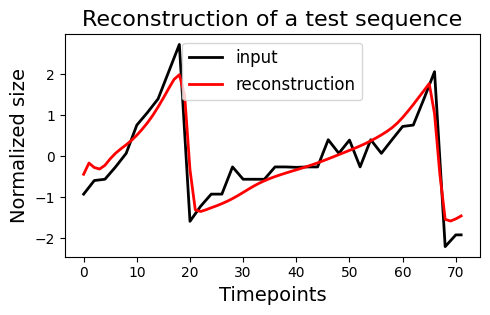

In [17]:
sequence_length = 72
number_of_features = 1

dload = './model_save' #model save directory
latent_length = 12
hidden_size = 90
hidden_layer_depth = 2
batch_size = 200
learning_rate = 0.001
n_epochs = 2 #200
dropout_rate = 0.2
optimizer = 'Adam'
cuda = True
print_every=1000
clip = True
max_grad_norm=5
loss = 'MSELoss'
block = 'LSTM'

vrae_trained_12 = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained_12.load(fr'C:\Users\achfr\single_cell_time_series_representation_learning\saved_models\vrae_autoencoder_12.pth')

vrae_trained_12.eval()

k=np.random.randint(0,len(array_x_aug_scaled))
print(k)
testseq2 = torch.from_numpy(np.tile(array_x_aug_scaled[k], (200, 1, 1))).float().permute(1, 0,2).cuda()
outp = vrae_trained_12.forward(testseq2)

k=np.random.randint(0,batch_size)
k=160
input_seq = testseq2[:,k,0].cpu().detach().numpy()
output_seq = outp[0][:,k,0].cpu().detach().numpy()

plt.figure(figsize=(5,13/4))
plt.plot(input_seq.T, color ='black',linewidth = 2, label='input')
plt.plot(output_seq.T, color='red',linewidth = 2, label='reconstruction')
plt.xlabel('Timepoints', fontsize=14)
plt.ylabel('Normalized size', fontsize=14)
plt.title('Reconstruction of a test sequence', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

In [6]:
#encode everything
from tqdm import tqdm
encoded_data = []
for i in tqdm(range(array_x_aug_scaled.shape[0])):
    encoded_data.append(encode_sequence_1dim(vrae_trained_12, array_x_aug_scaled[i,:,0]))
encoded_data = np.array(encoded_data)

100%|██████████| 19286/19286 [00:19<00:00, 1004.49it/s]


In [18]:
#creating data subset for plotting
all_controls = np.array([encoded_data[i] for i in range(len(liste_y_aug)) if liste_y_aug[i][1] == 'control'])
glu_cip =    np.array([encoded_data[i] for i in range(len(liste_y_aug)) if liste_y_aug[i][1] == 'cip' and liste_y_aug[i][0] == 'glu'])
glu_tet =    np.array([encoded_data[i] for i in range(len(liste_y_aug)) if liste_y_aug[i][1] == 'tet' and liste_y_aug[i][0] == 'glu'])
glu_ciptet = np.array([encoded_data[i] for i in range(len(liste_y_aug)) if liste_y_aug[i][1] == 'ciptet' and liste_y_aug[i][0] == 'glu'])

plotting_data = [encoded_data, all_controls, glu_cip, glu_tet, glu_ciptet]
plotnames = ['all_data', 'all_controls', 'glu_cip', 'glu_tet', 'glu_ciptet']

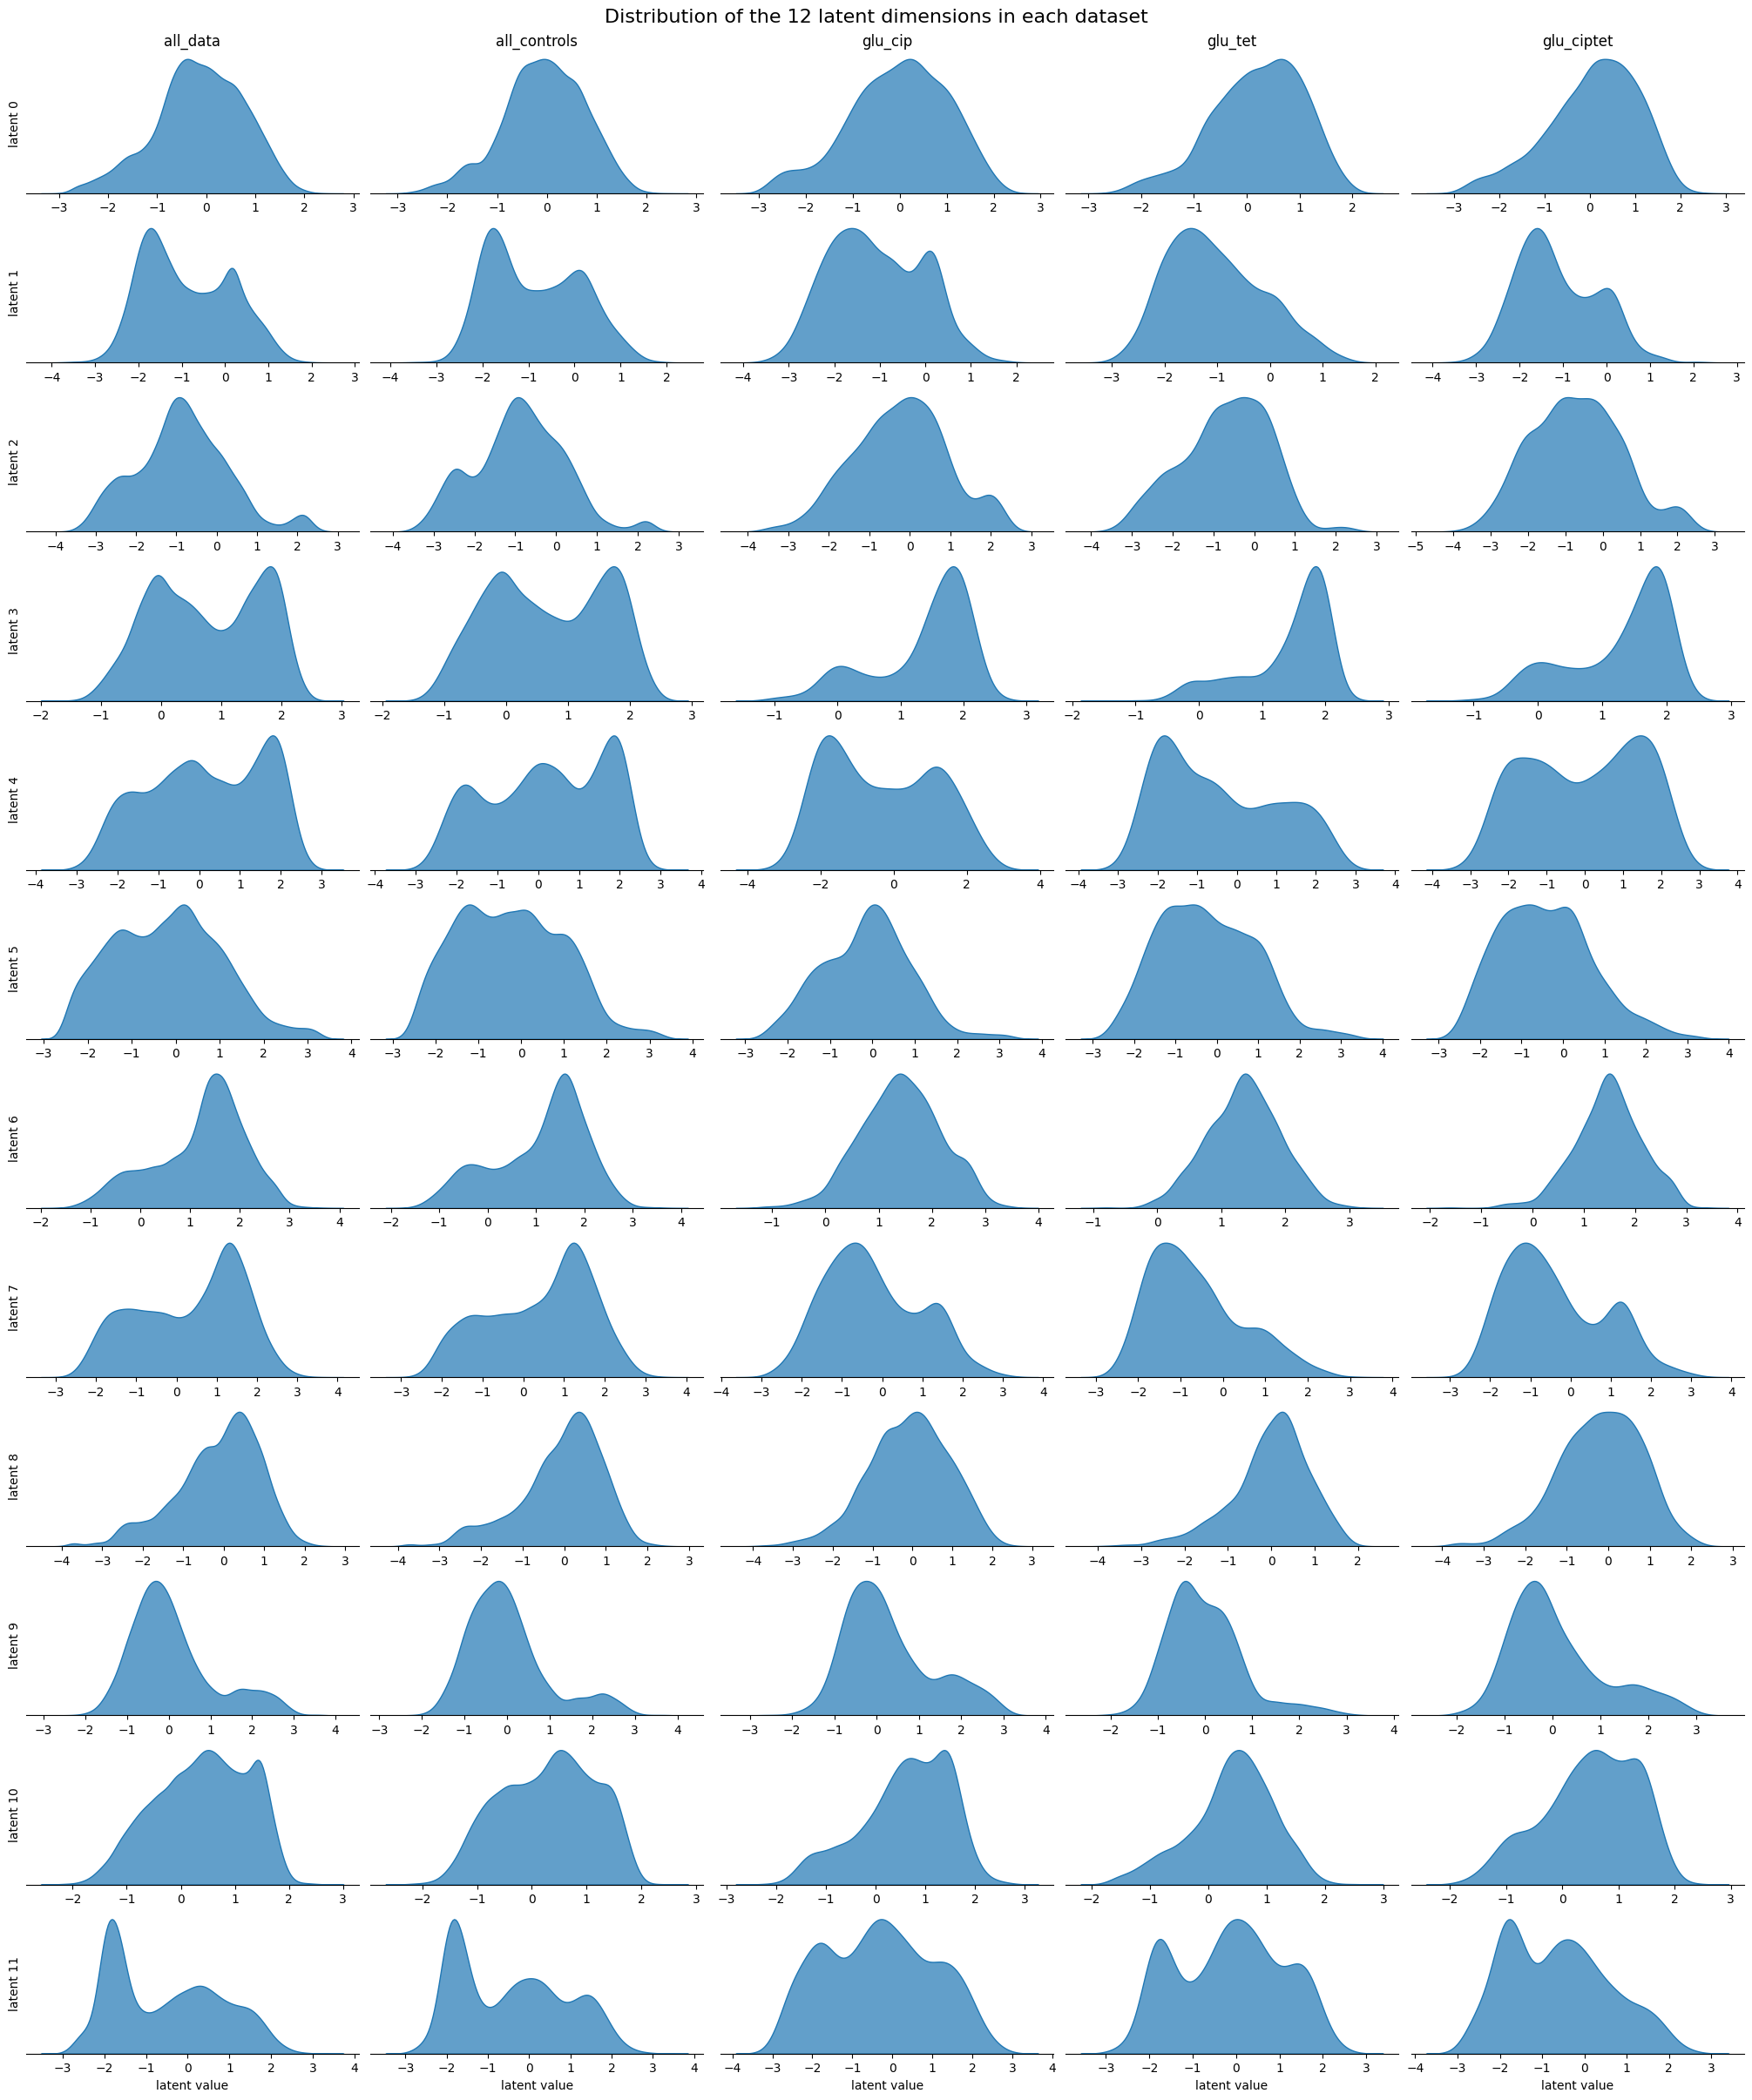

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot distribution of each of the 12 latent dimensions for each dataset in plotting_data
fig, axes = plt.subplots(nrows=12, ncols=5, figsize=(20, 24), constrained_layout=True)

for col_idx, data in enumerate(plotting_data):
    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    for row_idx in range(12):
        ax = axes[row_idx, col_idx]
        if row_idx < data.shape[1]:
            values = data[:, row_idx]
            sns.kdeplot(values, fill=True, ax=ax, color='tab:blue', alpha=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_yticks([])
        else:
            ax.axis('off')
        if row_idx == 0:
            ax.set_title(plotnames[col_idx], fontsize=12)
        if row_idx == 11:
            ax.set_xlabel('latent value', fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f'latent {row_idx}', fontsize=10)
        else:
            ax.set_ylabel('')

plt.suptitle('Distribution of the 12 latent dimensions in each dataset', fontsize=16)
plt.show()

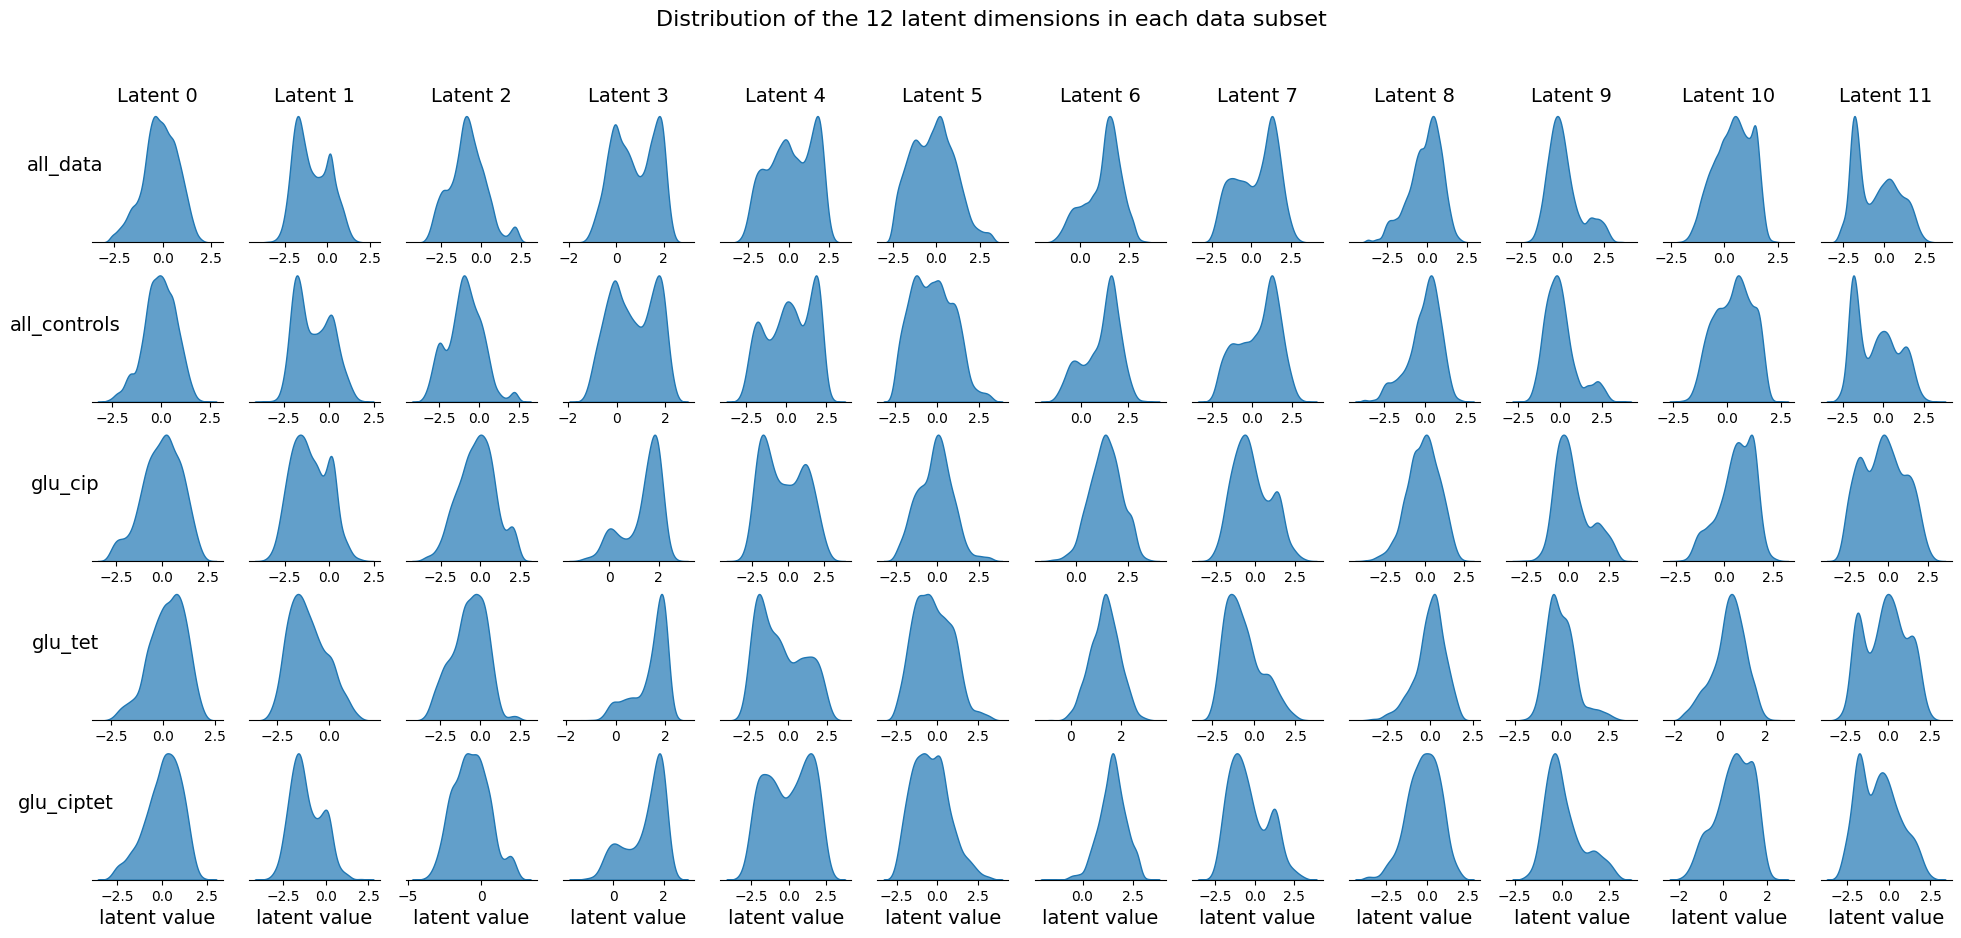

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
#increase label size for better readability
# plot distribution of each of the 12 latent dimensions for each dataset in plotting_data
fig, axes = plt.subplots(nrows=5, ncols=12, figsize=(24, 10))#, constrained_layout=True)

for row_idx, data in enumerate(plotting_data):
    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    for col_idx in range(12):
        ax = axes[row_idx, col_idx]
        if col_idx < data.shape[1]:
            values = data[:, col_idx]
            sns.kdeplot(values, fill=True, ax=ax, color='tab:blue', alpha=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_yticks([])
        else:
            ax.axis('off')
        if row_idx == 0:
            ax.set_title(f'Latent {col_idx}', fontsize=14)
        if row_idx == 4:
            ax.set_xlabel('latent value', fontsize=14)
        if col_idx == 0:
            ax.set_ylabel(plotnames[row_idx], fontsize=14)
            #rotate the y-axis label
            ax.yaxis.set_label_coords(-0.2, 0.5)
            ax.yaxis.label.set_rotation(0)
        else:
            ax.set_ylabel('')

plt.suptitle('Distribution of the 12 latent dimensions in each data subset', fontsize=16)
plt.show()

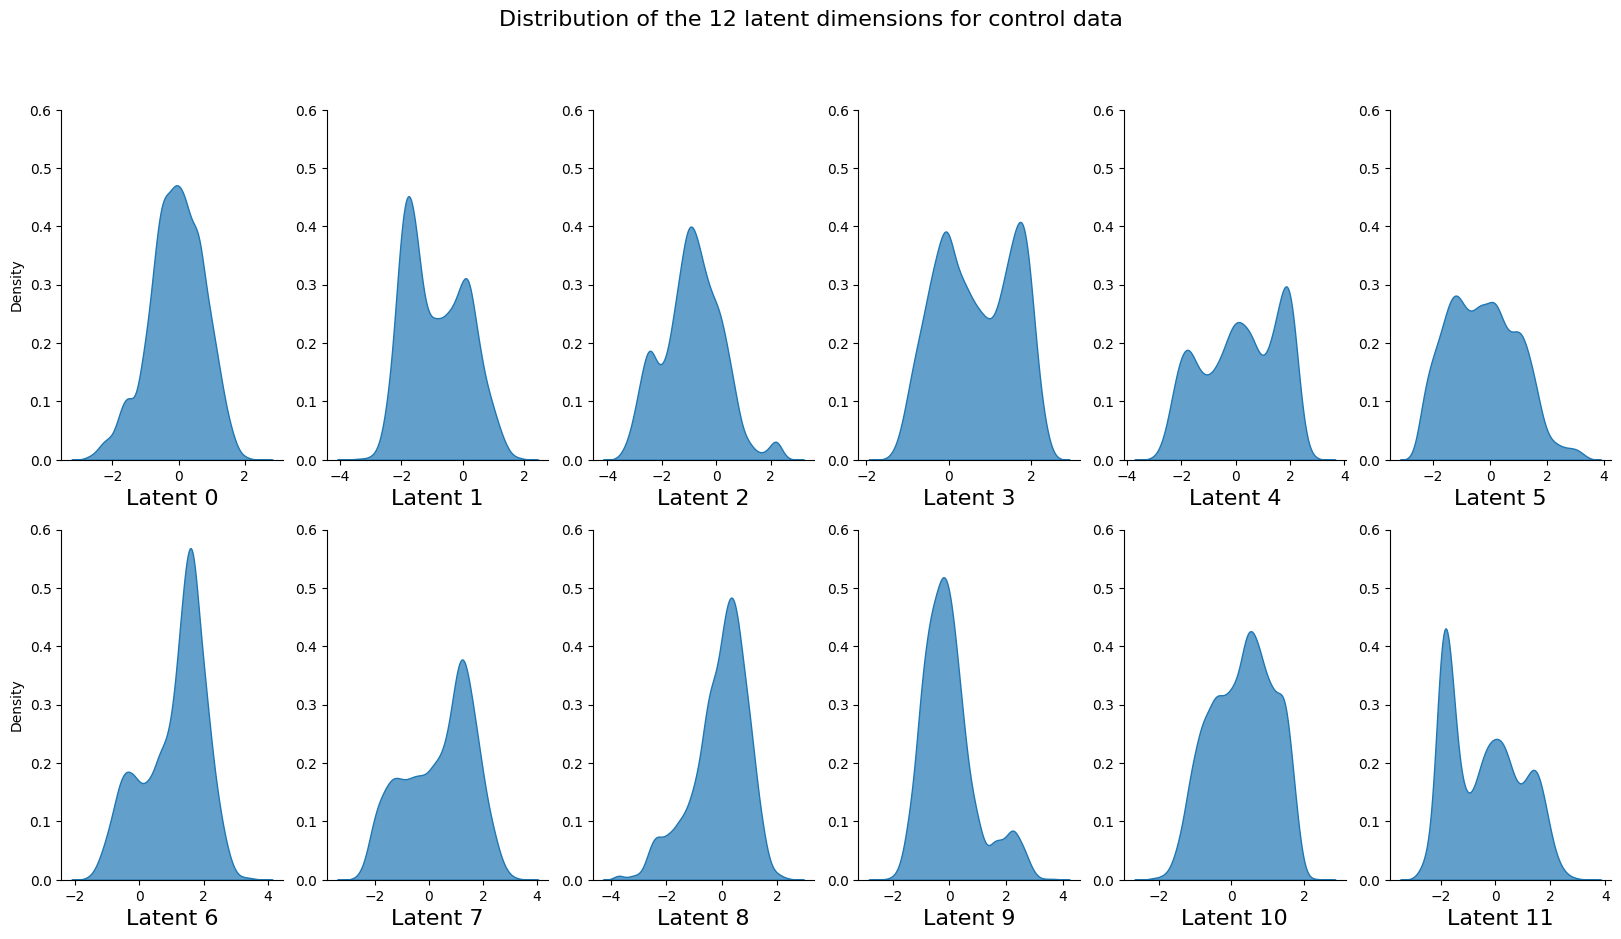

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
#increase label size for better readability
# plot distribution of each of the 12 latent dimensions for each dataset in plotting_data
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(20, 10))#, constrained_layout=True)

data = plotting_data[1]
for col_idx,ax in enumerate(axes.flatten()):
            values = data[:, col_idx]
            sns.kdeplot(values, fill=True, ax=ax, color='tab:blue', alpha=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            # ax.spines['left'].set_visible(False)
            # ax.set_yticks([])
            ax.set_ylim([0,0.6])
            ax.set_xlabel(f'Latent {col_idx}', fontsize=16)
            if col_idx not  in [0,6]:
                    ax.set_ylabel('')

plt.suptitle('Distribution of the 12 latent dimensions for control data', fontsize=16)
plt.show()